# PINN example notebook: Logistic Regression

This is an example notebook to learn the basics of Pysics Informed Neural Networks (PINNs) with a very simple example:|
Logistic Regression

The differential equation for logistic regression can be solved analytically. \
Using a neural network to learn this solution to the problem aims to explain the concept and application of a PINN to differential equations in general.

# Import Libraries

In [1]:
import torch 
import torchopt
from torch import nn

import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np

from functorch import make_functional
from torch.func import grad, vmap

import torch.nn as nn

# Create a model class

In [2]:
# NNApproximator will be the neural network consisting of an input layer, 
# an output layer, hidden layers in betwee n and tanh as activation function
class NNApproximator(nn.Module):
    def __init__(
        self,
        num_inputs: int = 1,
        num_outputs: int = 1,
        num_hidden: int = 2,
        dim_hidden: int = 2,
        act: nn.Module = nn.Tanh(),
    ) -> None:
        """Simple neural network with linear layers and non-linear activation function
        This class is used as universal function approximator for the solution of
        partial differential equations using PINNs
        Args:
            num_inputs (int, optional): The number of input dimensions
            num_outputs (int, optional): The number of outputs of the model, in general is 1
            num_hidden (int, optional): The number of hidden layeim_hidden rs in the model
            dim_hidden (int, optional): The number of neurons for each hidden layer
            act (nn.Module, optional): The type of non-linear activation function to be used
        """
        super().__init__()

        # creates linear input and output layers 
        
        # input layer has num_input inputs neurons and dim_hidden outputs
        self.layer_in = nn.Linear(num_inputs, dim_hidden)
        # output layer has dim_hidden inputs neurons and num_outputs outputs
        self.layer_out = nn.Linear(dim_hidden, num_outputs)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

        self.num_inputs = num_inputs
        self.num_outputs = num_outputs

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act(self.layer_in(x))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        return self.layer_out(out)


# Intialisation of the model

In [3]:
# create the PINN model
model = NNApproximator()
# create a dictionary using the parameter names connected with its values
params = dict(model.named_parameters())

# Applying vmap and grad

In [4]:
# Define a function that applies the model to an input vector 
# using the squeeze method to get x into the right form
def apply_model(x):
    
    return model(x.unsqueeze(0)).squeeze(0)

# Apply the model to the input using vmap
model_v = torch.vmap(apply_model)

# computing its derivative using grad 
# important: first apply grad and then use the vmap. You can only grad scalar functions.
diff_model= torch.func.grad(apply_model)
diff_model_v= torch.vmap(diff_model)

# Defining a loss function

In [5]:
R = 1.0  # rate of maximum population growth parameterizing the equation
X_BOUNDARY = 0.0  # boundary condition coordinate
F_BOUNDARY = 0.5  # boundary condition value

# defining a loss function consisting of two parts
# first part calculates the loss in resect to the differential equation
# second parts sets bounday conditions so that the solution converges
def loss_fn(params: torch.Tensor, x: torch.Tensor, model_v) -> torch.Tensor:

    # interior loss
    f_value = model_v(x)
    
    interior = diff_model_v(x)- R * f_value * (1 - f_value)

    # boundary loss
    x0 = X_BOUNDARY
    f0 = F_BOUNDARY
    x_boundary = torch.tensor([x0])
    f_boundary = torch.tensor([f0])
    # calculates difference between the the functional value at the boundary and the aimed value
    boundary = model_v(x_boundary)- f_boundary

    # calculates the mean squared error using the nn.MSELoss function
    loss = nn.MSELoss()
    # adding both losses to a total loss
    # the loss function takes its two inputs and calculates the mse of those
    # therefore the second entry is a tensor with the same dimensions but with zeroes 
    loss_value = loss(interior, torch.zeros_like(interior)) + loss(
        boundary, torch.zeros_like(boundary)
    )

    return loss_value

# Training the model

In [6]:
# choose the configuration
batch_size = 30  # number of colocation points sampled in the domain
num_iter =1000 # maximum number of iterations
learning_rate = 1e-3  # learning rate
domain = (-5.0, 5.0)  # logistic equation domain

# choose optimizer with functional API using functorch


#list that keeps track of the loss evolution
loss_evolution = []

# train the model
for i in range(num_iter):

    # sample colocations points in the domain randomly at each epoch
    x = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1])
    output = model_v(x)
    
    #initializing  the optimizer with model parameters
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # update the parameters using the functional API
    loss = loss_fn(params, x, model_v)
    optimizer.zero_grad()  # Clear the gradients
    loss.backward()  # Compute gradients
    optimizer.step()  # Update the model parameters
    

    print(f"Iteration {i} with loss {float(loss)}")
    
    #appends the loss from every iteration to the loss_evolution list
    loss_evolution.append(float(loss))

# plot solution on the given domain



Iteration 0 with loss 0.09960642457008362
Iteration 1 with loss 0.09914994239807129
Iteration 2 with loss 0.09783317148685455
Iteration 3 with loss 0.09700307250022888
Iteration 4 with loss 0.09720520675182343
Iteration 5 with loss 0.0947733074426651
Iteration 6 with loss 0.09447305649518967
Iteration 7 with loss 0.09253498911857605
Iteration 8 with loss 0.09288577735424042
Iteration 9 with loss 0.09214015305042267
Iteration 10 with loss 0.090020090341568
Iteration 11 with loss 0.08888652920722961
Iteration 12 with loss 0.08635973930358887
Iteration 13 with loss 0.0860329270362854
Iteration 14 with loss 0.08516626060009003
Iteration 15 with loss 0.08499293029308319
Iteration 16 with loss 0.08477351069450378
Iteration 17 with loss 0.08291207253932953
Iteration 18 with loss 0.08144181966781616
Iteration 19 with loss 0.08183787763118744
Iteration 20 with loss 0.08059105277061462
Iteration 21 with loss 0.07915714383125305
Iteration 22 with loss 0.07691048085689545
Iteration 23 with loss 0.

Iteration 200 with loss 0.01252495776861906
Iteration 201 with loss 0.010699794627726078
Iteration 202 with loss 0.011040689423680305
Iteration 203 with loss 0.010217364877462387
Iteration 204 with loss 0.011047101579606533
Iteration 205 with loss 0.010480922646820545
Iteration 206 with loss 0.010686900466680527
Iteration 207 with loss 0.009633100591599941
Iteration 208 with loss 0.010646548122167587
Iteration 209 with loss 0.00862422026693821
Iteration 210 with loss 0.00989559106528759
Iteration 211 with loss 0.008423916064202785
Iteration 212 with loss 0.008281391113996506
Iteration 213 with loss 0.008263709023594856
Iteration 214 with loss 0.008260931819677353
Iteration 215 with loss 0.00744605902582407
Iteration 216 with loss 0.007251805625855923
Iteration 217 with loss 0.007455372251570225
Iteration 218 with loss 0.006460437085479498
Iteration 219 with loss 0.006266963668167591
Iteration 220 with loss 0.005816207267343998
Iteration 221 with loss 0.0062601566314697266
Iteration 222

Iteration 406 with loss 0.000823525246232748
Iteration 407 with loss 0.001605538884177804
Iteration 408 with loss 0.0011733925202861428
Iteration 409 with loss 0.0012012725928798318
Iteration 410 with loss 0.0009369261679239571
Iteration 411 with loss 0.0012461821315810084
Iteration 412 with loss 0.0009557029115967453
Iteration 413 with loss 0.0012126591755077243
Iteration 414 with loss 0.001341133494861424
Iteration 415 with loss 0.0009554166463203728
Iteration 416 with loss 0.00100601720623672
Iteration 417 with loss 0.0010238918475806713
Iteration 418 with loss 0.0011115120723843575
Iteration 419 with loss 0.0005887356237508357
Iteration 420 with loss 0.0011278708698228002
Iteration 421 with loss 0.0005582838202826679
Iteration 422 with loss 0.0013508443953469396
Iteration 423 with loss 0.001353699597530067
Iteration 424 with loss 0.0008315478917211294
Iteration 425 with loss 0.0007364217308349907
Iteration 426 with loss 0.0006570014520548284
Iteration 427 with loss 0.00115261448081

Iteration 585 with loss 0.0004466694954317063
Iteration 586 with loss 0.0004798082809429616
Iteration 587 with loss 0.0005072739440947771
Iteration 588 with loss 0.0006519978633150458
Iteration 589 with loss 0.0004982695681974292
Iteration 590 with loss 0.00039926357567310333
Iteration 591 with loss 0.0005714921862818301
Iteration 592 with loss 0.00050311628729105
Iteration 593 with loss 0.0003759883693419397
Iteration 594 with loss 0.0004319812869653106
Iteration 595 with loss 0.0005148657946847379
Iteration 596 with loss 0.0004958596546202898
Iteration 597 with loss 0.0002719384792726487
Iteration 598 with loss 0.0002976653922814876
Iteration 599 with loss 0.00042065518209710717
Iteration 600 with loss 0.0005856763455085456
Iteration 601 with loss 0.000454375782283023
Iteration 602 with loss 0.0006959997699595988
Iteration 603 with loss 0.0003590803826227784
Iteration 604 with loss 0.0004437155439518392
Iteration 605 with loss 0.0003793008509092033
Iteration 606 with loss 0.000372928

Iteration 779 with loss 0.00028321915306150913
Iteration 780 with loss 0.00021205359371379018
Iteration 781 with loss 0.0002114671078743413
Iteration 782 with loss 0.00017184460011776537
Iteration 783 with loss 0.00019138013885822147
Iteration 784 with loss 0.00021207849204074591
Iteration 785 with loss 0.0002289228286826983
Iteration 786 with loss 0.0001293044479098171
Iteration 787 with loss 0.0002148466883227229
Iteration 788 with loss 0.0002119302371283993
Iteration 789 with loss 0.00024852369097061455
Iteration 790 with loss 0.00018664333038032055
Iteration 791 with loss 0.00020841433433815837
Iteration 792 with loss 0.0002021674590650946
Iteration 793 with loss 0.0001830182591220364
Iteration 794 with loss 0.000183960422873497
Iteration 795 with loss 0.000222799411858432
Iteration 796 with loss 0.0001548616128275171
Iteration 797 with loss 0.00019027503731194884
Iteration 798 with loss 0.00029138417448848486
Iteration 799 with loss 0.0001731118536554277
Iteration 800 with loss 0.

Iteration 981 with loss 0.0001311195082962513
Iteration 982 with loss 0.00011920246470253915
Iteration 983 with loss 0.00013115863839630038
Iteration 984 with loss 0.0001351618266198784
Iteration 985 with loss 9.556426084600389e-05
Iteration 986 with loss 7.720654684817418e-05
Iteration 987 with loss 8.851165330270305e-05
Iteration 988 with loss 8.045230788411573e-05
Iteration 989 with loss 0.00011827759590232745
Iteration 990 with loss 7.95758533058688e-05
Iteration 991 with loss 6.440829747589305e-05
Iteration 992 with loss 8.445894491160288e-05
Iteration 993 with loss 7.607626321259886e-05
Iteration 994 with loss 0.00010245723387924954
Iteration 995 with loss 9.044655598700047e-05
Iteration 996 with loss 9.175065497402102e-05
Iteration 997 with loss 7.527362322434783e-05
Iteration 998 with loss 0.00010331392695661634
Iteration 999 with loss 0.00013161810056772083


# Plotting the solution and the loss evolution

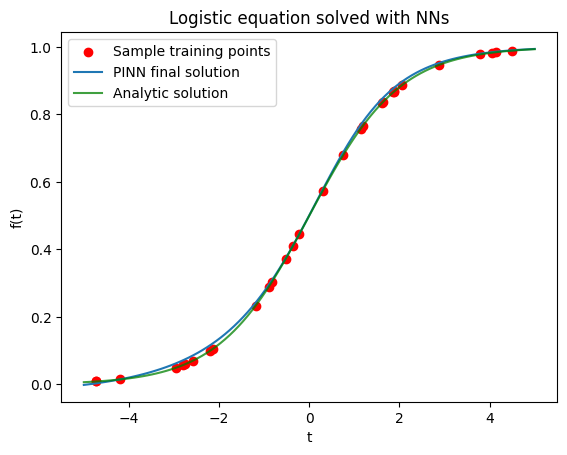

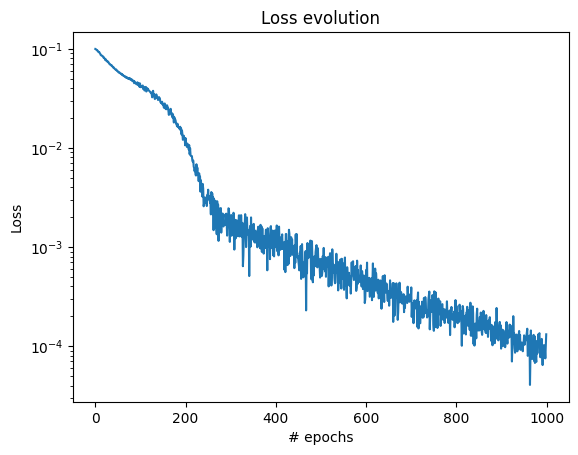

In [7]:
# creates list, with entries between 0 and 1 in 100 steps. 
# reshape brings it in form of a vector 
# -1 => the vector has as many rows as entries
# 1 => the vector has one column
x_eval = torch.linspace(domain[0], domain[1], steps=100).reshape(-1, 1)

# evaluates the function values to the given x values
f_eval = model_v(x_eval).squeeze()

# creates a analytical solution for comparison purposes
analytical_sol_fn = lambda x: 1.0 / (1.0 + (1.0/F_BOUNDARY - 1.0) * np.exp(-R * x))

# creates a numpy array from x_eval and detaches it from x_eval
x_eval_np = x_eval.detach().numpy()

# creates an numpy array with the x values of the sample points
x_sample_np = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1]).detach().numpy()

#creates Figures and axes for the first plot

fig, ax = plt.subplots()

# creates a scatter plot of the Sample training points
ax.scatter(x_sample_np, analytical_sol_fn(x_sample_np), color="red", label="Sample training points")
# ads the PINN solution, analytical solution, title and legend to the plot
ax.plot(x_eval_np, f_eval.detach().numpy(), label="PINN final solution")
ax.plot(
    x_eval_np,
    analytical_sol_fn(x_eval_np),
    label=f"Analytic solution",
    color="green",
    alpha=0.75,
)
ax.set(title="Logistic equation solved with NNs", xlabel="t", ylabel="f(t)")
ax.legend()

#creates Figures and axes for the second plot
fig, ax = plt.subplots()
ax.semilogy(loss_evolution) #y-axis is logarithmic
ax.set(title="Loss evolution", xlabel="# epochs", ylabel="Loss")


plt.show()